In [1]:
%load_ext autoreload
%autoreload 2

文献内容复现 part 1
> Constructing micro-rheological model for lithium-ion battery electrode slurry for coating window prediction

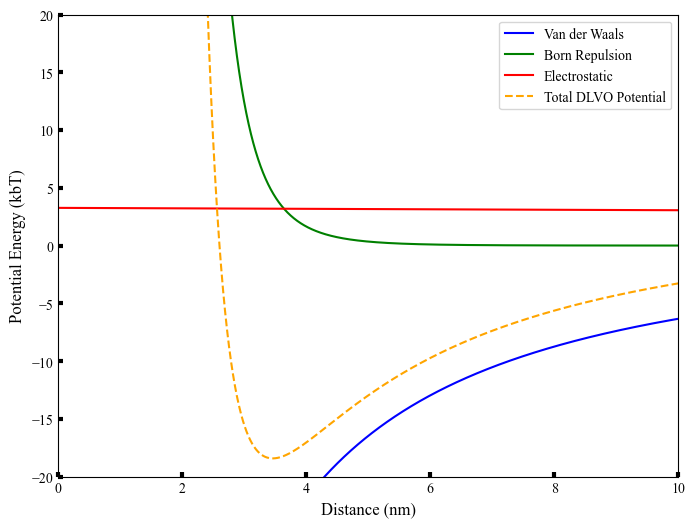

In [11]:
# 文献内容复现
import matplotlib.pyplot as plt
from utils.tools import cal_dlvo
from utils.imgtools import PlotOverlay

kb = 1.38e-23  # 玻尔兹曼常数 (J/K)
TT = 298.15  # 温度 (K)

hh_list, vdw_list, born_list, ele_list, v_list= cal_dlvo() # 国际单位制
hh_list = [hh * 1e9 for hh in hh_list]  # 将距离转换为纳米单位
vdw_list = [i / (kb*TT) for i in vdw_list]  # 将势能转换为kBT单位
born_list = [i / (kb*TT) for i in born_list]  # 将势能转换为kBT单位
ele_list = [i / (kb*TT) for i in ele_list]  # 将势能转换为kBT单位
v_list = [i / (kb*TT) for i in v_list]  # 将总势能转换为kBT单位

plotter = PlotOverlay(figsize=(8, 6), xlabel='Distance (nm)', ylabel='Potential Energy (kbT)', ft=12, \
                      is_xlog=False, is_ylog=False, xlim=(0, 10), ylim=(-20, 20))

plotter.add_data(hh_list, vdw_list, label='Van der Waals', marker=None, color='blue')
plotter.add_data(hh_list, born_list, label='Born Repulsion', marker=None, color='green')
plotter.add_data(hh_list, ele_list, label='Electrostatic', marker=None, color='red')
plotter.add_data(hh_list, v_list, label='Total DLVO Potential', marker=None, color='orange', linestyle='--')  # 添加总势能曲线

plotter.show()

In [12]:
# 获取吸附参数
from utils.tools import cal_param, cal_rheology
hh_list, vdw_list, born_list, ele_list, v_list= cal_dlvo()
uc, hc, fc, k0 = cal_param(hh_list, v_list, verbose=True)
# 计算流变曲线
gama_list, eta_list, phi_a_list = cal_rheology(
    # uc=uc, hc=hc, fc=fc, k0=k0,
    verbose=True
    )

Uc(kbT): 18.42	 hc(e-9): 3.46	 Fc(e-12): 17.40	 k0: 12.81
gama: 0.010	 eta: 837.594	 qa: 4.822	 eta1 0.012	 eta2 837.582
gama: 0.032	 eta: 264.879	 qa: 4.822	 eta1 0.012	 eta2 264.867
gama: 0.100	 eta: 83.770	 qa: 4.822	 eta1 0.012	 eta2 83.758
gama: 0.316	 eta: 26.499	 qa: 4.822	 eta1 0.012	 eta2 26.487
gama: 1.000	 eta: 8.388	 qa: 4.820	 eta1 0.012	 eta2 8.376
gama: 3.162	 eta: 2.661	 qa: 4.815	 eta1 0.012	 eta2 2.649
gama: 10.000	 eta: 0.849	 qa: 4.800	 eta1 0.012	 eta2 0.838
gama: 31.623	 eta: 0.277	 qa: 4.752	 eta1 0.012	 eta2 0.265
gama: 100.000	 eta: 0.096	 qa: 4.613	 eta1 0.012	 eta2 0.084
gama: 316.228	 eta: 0.038	 qa: 4.261	 eta1 0.012	 eta2 0.026
gama: 1000.000	 eta: 0.018	 qa: 3.728	 eta1 0.011	 eta2 0.007
gama: 3162.278	 eta: 0.010	 qa: 3.133	 eta1 0.008	 eta2 0.001
gama: 10000.000	 eta: 0.007	 qa: 2.432	 eta1 0.006	 eta2 0.000


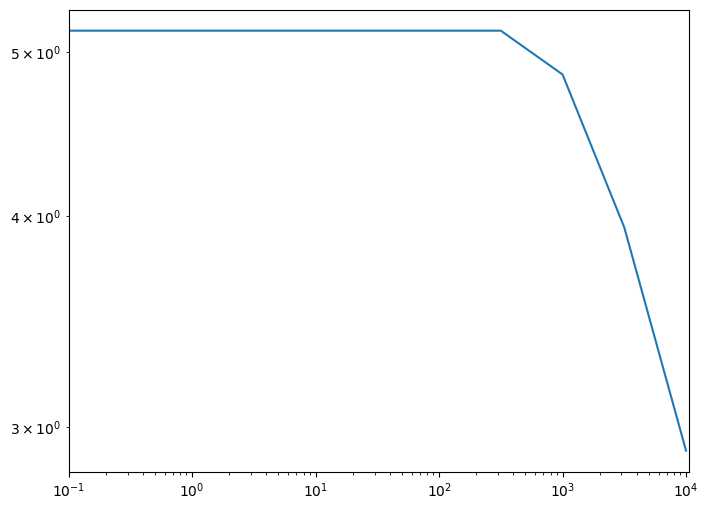

In [4]:
y = [i/(3.20345 * 0.02) for i in phi_a_list] # phia / phip
x = gama_list
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, y)
ax.set_xlim(left=0.1)
# ax.set_ylim(0, 300)
ax.set_yscale('log')
ax.set_xscale('log')
plt.show()

复现文献中流变曲线

Uc(kbT): 36.57	 hc(e-9): 2.09	 Fc(e-12): 50.15	 k0: 12.71
Counter Overflow!


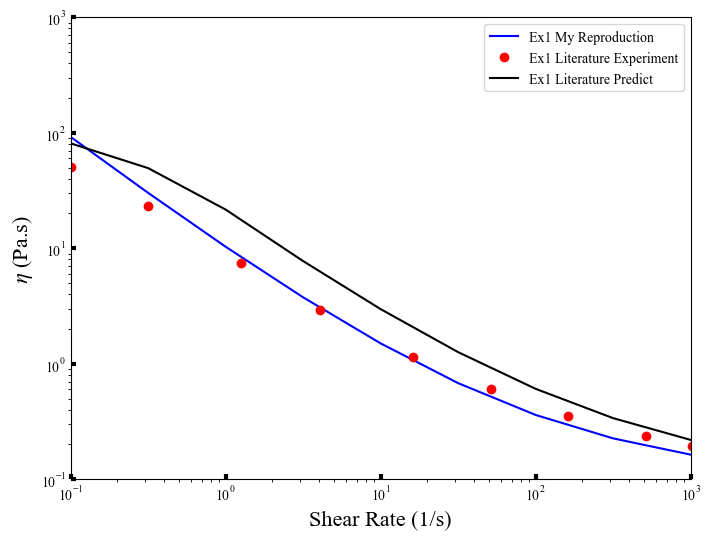

In [31]:
from utils.tools import cal_miu, cal_dlvo, cal_param, cal_rheology, show_rheology
import pandas as pd
import matplotlib.pyplot as plt
from utils.imgtools import PlotOverlay

# Figure 5(A)
w_pvdf = 0.0291
miu = cal_miu(w_pvdf, mode='5130')

# AM: PVDF+NMC, 0.238
phi_am = 0.234
phi_m = 0.6 # AM假设值
eta_am = miu * (1 - phi_am/ phi_m)**(-2)

# print(eta_am)

# PVDF+CB
sigma = (6 - 4 * w_pvdf**0.15)*1e-9 # m
dl = 1.3 + w_pvdf**0.3
phi_p = 3.20345 * 0.0133 # 作者回应必须乘上3.20345, 但为什么要乘原因不明

hh_list, vdw_list, born_list, ele_list, v_list = cal_dlvo(sigma=sigma)
uc, hc, fc, k0 = cal_param(hh_list, v_list, verbose=True)
gama_list, eta_list, _ = cal_rheology(uc=uc, hc=hc, fc=fc, k0=k0, dl=dl, 
                                   miu=miu, phi_p=phi_p, verbose=False)

# TODO:注意，这里是手动修改了phi_p的值为0.04

# Complete
# miu

# 还是画图对比一下, 只比较eta_cb

plotter = PlotOverlay(figsize=(8,6), xlim=(0.1,1000), ylim=(0.1,1000), is_xlog=True, is_ylog=True)
plotter.add_data(gama_list, eta_list, label='Ex1 My Reproduction', color='blue')

# 文献原始数据
df = pd.read_excel('./data/figures_manuscript.xlsx',sheet_name='figure 5-a', usecols='A:F', skiprows=2)
df = df.iloc[:, :2]

plotter.add_data(df.iloc[:, 0], df.iloc[:, 1], marker='o', linestyle='None',label='Ex1 Literature Experiment', color='red')

# 文献仿真结果
df = pd.read_excel('./data/figures_manuscript.xlsx', sheet_name='figure 5-a', usecols='H:K', skiprows=2)
df = df.iloc[:, :2]
plotter.add_data(df.iloc[:, 0], df.iloc[:, 1], label='Ex1 Literature Predict')
plotter.show()
# 原因分析
# 1) 缺少phi_m √ 就是0.61
# 2) 最核心问题, phi_p的值如何确定?还要继续研究!phi_CB是否等于phi_p? √ phi_a根据phi_p计算得到


In [32]:
# Figure 5(B)
import pandas as pd
from matplotlib import pyplot as plt
# 自己复现
# Collision diameter and length dimension
from utils.tools import cal_dlvo, cal_param, cal_rheology, cal_miu, show_rheology
w_pvdf_list = [0, 0.005, 0.025]
phi_p = 0.0140

# Store calculated eta_list and gamma_list for each w_pvdf
calculated_eta_lists = []
calculated_gamma_lists = []

sigma_list = [(6 - 4 * w_pvdf**0.15)*1e-9 for w_pvdf in w_pvdf_list]
dl_list = [(1.3 + w_pvdf**0.3) for w_pvdf in w_pvdf_list]

for i in range(len(sigma_list)):
    sigma = sigma_list[i]
    dl = dl_list[i]
    w_pvdf = w_pvdf_list[i]
    miu = cal_miu(w_pvdf, mode='6020')
    # miu = 0.000
    
    print(f"w_pvdf: {w_pvdf:.3f}, sigma: {sigma:.3f}, miu: {miu:.3f}")
    hh_list, vdw_list, born_list, ele_list, v_list = cal_dlvo(sigma=sigma)
    uc, hc, fc, k0 = cal_param(hh_list, v_list, verbose=True)
    # 还要考虑miu随w_pvdf的变化
    # uc = 30*kb*TT
    gama_list, eta_list, _ = cal_rheology(uc=uc, hc=hc, fc=fc, k0=k0, dl=dl , miu=miu, phi_p=phi_p, verbose=True)

    calculated_eta_lists.append(eta_list)
    calculated_gamma_lists.append(gama_list)

    # break


w_pvdf: 0.000, sigma: 0.000, miu: 0.002
Uc(kbT): 18.42	 hc(e-9): 3.46	 Fc(e-12): 17.40	 k0: 12.81
gama: 0.010	 eta: 85.717	 qa: 7.716	 eta1 0.006	 eta2 85.711
gama: 0.032	 eta: 27.108	 qa: 7.716	 eta1 0.006	 eta2 27.102
gama: 0.100	 eta: 8.575	 qa: 7.715	 eta1 0.006	 eta2 8.569
gama: 0.316	 eta: 2.714	 qa: 7.713	 eta1 0.006	 eta2 2.708
gama: 1.000	 eta: 0.860	 qa: 7.706	 eta1 0.006	 eta2 0.855
gama: 3.162	 eta: 0.274	 qa: 7.685	 eta1 0.006	 eta2 0.269
gama: 10.000	 eta: 0.089	 qa: 7.621	 eta1 0.006	 eta2 0.083
gama: 31.623	 eta: 0.030	 qa: 7.435	 eta1 0.005	 eta2 0.025
gama: 100.000	 eta: 0.012	 qa: 6.974	 eta1 0.005	 eta2 0.007
gama: 316.228	 eta: 0.006	 qa: 6.091	 eta1 0.004	 eta2 0.002
gama: 1000.000	 eta: 0.003	 qa: 4.877	 eta1 0.003	 eta2 0.000
gama: 3162.278	 eta: 0.003	 qa: 3.647	 eta1 0.003	 eta2 0.000
gama: 10000.000	 eta: 0.002	 qa: 2.624	 eta1 0.002	 eta2 0.000
w_pvdf: 0.005, sigma: 0.000, miu: 0.002
Uc(kbT): 30.46	 hc(e-9): 2.40	 Fc(e-12): 37.39	 k0: 12.76
gama: 0.010	 eta:

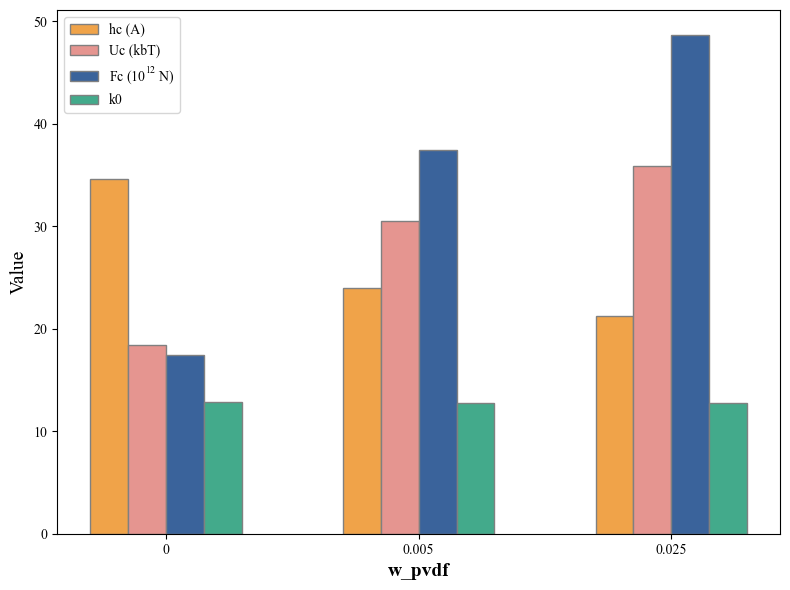

In [36]:
import matplotlib.pyplot as plt
import numpy as np

my_Uc_list = [18.42, 30.46, 35.89]
my_hc_list = [3.46, 2.40, 2.12]
my_hc_list = [i*10 for i in my_hc_list]
my_Fc_list = [17.40, 37.39, 48.66]
my_k0_list = [12.81, 12.76, 12.76]
w_pvdf = [0, 0.005, 0.025]

# Define bar width and positions
bar_width = 0.15
r1 = np.arange(len(w_pvdf))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]
r4 = [x + bar_width for x in r3]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size as needed

# Define colors and labels - colors from the image
colors = ['#F0A349', '#E59590', '#3A639B', '#43AA8B']  # Exact colors from the image (approximate)
labels = ['hc (A)', 'Uc (kbT)', 'Fc ($10^{12}$ N)', 'k0']  # Use proper superscript and spacing

# Plot the bars
ax.bar(r1, my_hc_list, color=colors[0], width=bar_width, edgecolor='grey', label=labels[0])
ax.bar(r2, my_Uc_list, color=colors[1], width=bar_width, edgecolor='grey', label=labels[1])
ax.bar(r3, my_Fc_list, color=colors[2], width=bar_width, edgecolor='grey', label=labels[2])
ax.bar(r4, my_k0_list, color=colors[3], width=bar_width, edgecolor='grey', label=labels[3])

# Add xticks and labels
plt.xlabel('w_pvdf', fontweight='bold')
plt.xticks([r + bar_width*1.5 for r in range(len(w_pvdf))], w_pvdf)  # Center x-axis labels
plt.ylabel('Value') # Add y axis label
#plt.title('Comparison of Parameters') # Add plot title (optional)

# Add legend
plt.legend()

# Adjust layout for better readability
plt.tight_layout()

# Show the plot
plt.show()


Counter Overflow!
Counter Overflow!
Counter Overflow!
Counter Overflow!
Counter Overflow!
Counter Overflow!


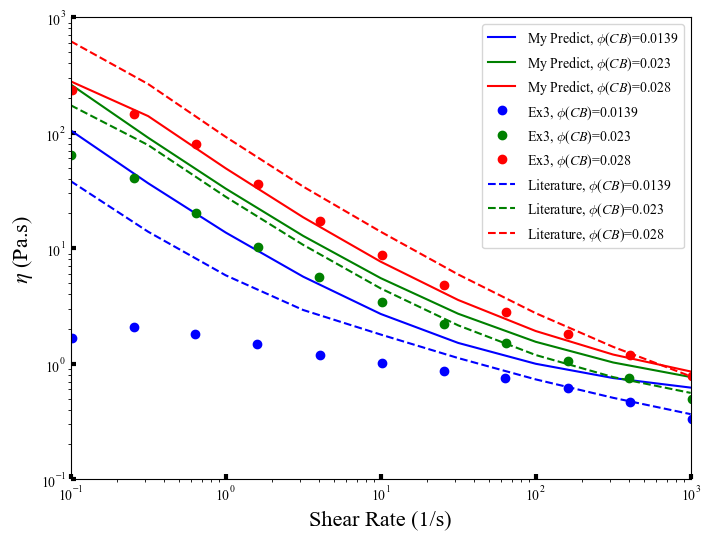

In [54]:
# 重点还是对改变碳黑浓度的案例进行复现

# Figure 5 (C)
from utils.tools import cal_miu, cal_dlvo, cal_param, cal_rheology
from utils.imgtools import PlotOverlay

w_pvdf = 0.05
miu = cal_miu(w_pvdf, mode='5130')
aa = 75e-9 # [m]

phi_am = 0 # phi_am = 0 !!!
phi_m = 0.6 # 最大堆积体积分数
eta_am = 0

simga = (6 - 4*w_pvdf**0.15)*1e-9
dl = 1.3 + w_pvdf**0.3

phi_p_origin_list = [0.0139, 0.0230, 0.0280]
phi_p_list = [x * 3.20345 for x in phi_p_origin_list ]
color_list = ['blue', 'green', 'red']
label_my_list = [f'My Predict, $\\phi (CB)$={x}' for x in phi_p_origin_list]

# 吸附力参数只受pvdf浓度影响，与CB无关
hh_list, vdw_list, born_list, ele_list, v_list = cal_dlvo(sigma=sigma)
uc, hc, fc, k0 = cal_param(hh_list, v_list)

plotter = PlotOverlay(figsize=(8,6), xlim=(0.1,1000), ylim=(0.1,1000), is_xlog=True, is_ylog=True)

for idx, phi_p in enumerate(phi_p_list):
    gama_list, eta_list, _ = cal_rheology(uc=uc, hc=hc, fc=fc, k0=k0, dl=dl,
                                      miu=miu, phi_p=phi_p)
    plotter.add_data(gama_list, eta_list, label=label_my_list[idx], color=color_list[idx])


# 对比原始数据
data = pd.read_excel('./data/figures_manuscript.xlsx',sheet_name='figure 5-c', usecols='A:F', skiprows=2)
df_list = [data.iloc[:, i:i+2] for i in list(range(0,6,2))]
label_ex3_list = [f'Ex3, $\\phi (CB)$={x}' for x in phi_p_origin_list]
for idx, df in enumerate(df_list):
    plotter.add_data(df.iloc[:, 0], df.iloc[:, 1], marker='o', linestyle='None',label=label_ex3_list[idx], color=color_list[idx])

# 对比文献复现数据
data2 = pd.read_excel('./data/figures_manuscript.xlsx',sheet_name='figure 5-c', usecols='H:K', skiprows=2)
df_lite_list = [data2.iloc[:, [0, i+1]] for i in range(3)]
label_lite_list = [f'Literature, $\\phi (CB)$={x}' for x in phi_p_origin_list]
for idx, df in enumerate(df_lite_list):
    plotter.add_data(df.iloc[:, 0], df.iloc[:, 1], marker=None, linestyle='--',label=label_lite_list[idx], color=color_list[idx])


plotter.show()
